|<img src="https://drive.google.com/uc?id=1kjzJXxk2dJDr_oNKOqgGjBPbu4v-s0NW" width="100px" height="100">| <p> Métodos Cuantitativos</p> <p>Ingeniería en Control de Gestión</p> <p>Unidad II: Test de Hipótesis y Regresión Lineal</p> <p>Sesión 10: Regresión lineal parte II</p>|
|:--- |:---|

## Acerca de los datos

El conjunto de datos sobre el Rendimiento Estudiantil ha sido creado con el propósito de analizar los factores que inciden en el desempeño académico de los estudiantes. Esta recopilación consta de 10.000 registros estudiantiles, en los cuales cada uno proporciona información sobre diversos predictores y un índice de rendimiento.

- **Variables:**
  - `horas_estudiadas`: El número total de horas dedicadas al estudio por cada estudiante.
  - `notas_previas`: Los puntajes obtenidos por los estudiantes en pruebas anteriores.
  - `actividades_extracurriculares`: Si el estudiante participa en actividades extracurriculares (Yes o No).
  - `horas_dormidas`: El número promedio de horas de sueño que el estudiante tuvo por día.
  - `nros_ensayos`: El número de cuestionarios de muestra que el estudiante practicó.
- **Variable Objetivo:**
  - `indice_rendimiento`: Una medida del desempeño general de cada estudiante. El índice de rendimiento representa el rendimiento académico del estudiante y se ha redondeado al entero más cercano. El índice varía de 10 a 100, siendo valores más altos indicativos de un mejor desempeño.

In [1]:
# @title Carga de datos
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/sebastiancontz/test/master/student_performance.csv"
data = pd.read_csv(url)

### Inspección de los datos

In [2]:
data.head()

,horas_estudiadas,notas_previas,actividades_extracurriculares,horas_dormidas,nros_ensayos,indice_rendimiento
0,7,99,Yes,9,1,91
1,4,82,No,4,2,65
2,8,51,Yes,7,2,45
3,5,52,Yes,5,2,36
4,7,75,No,8,5,66


In [3]:
data.describe()

,horas_estudiadas,notas_previas,horas_dormidas,nros_ensayos,indice_rendimiento
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


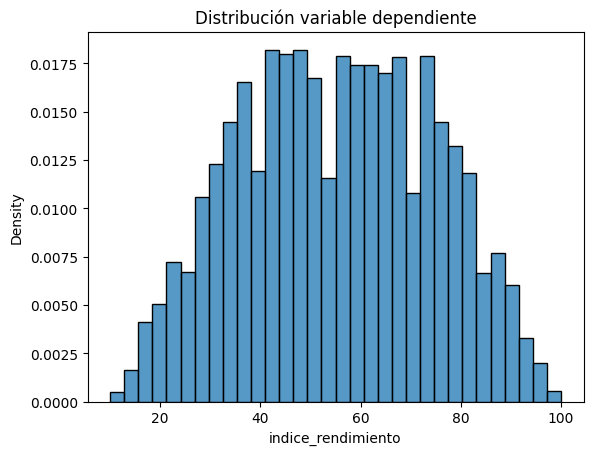

In [4]:
sns.histplot(data=data, x="indice_rendimiento", stat="density")
plt.title("Distribución variable dependiente")
plt.show()

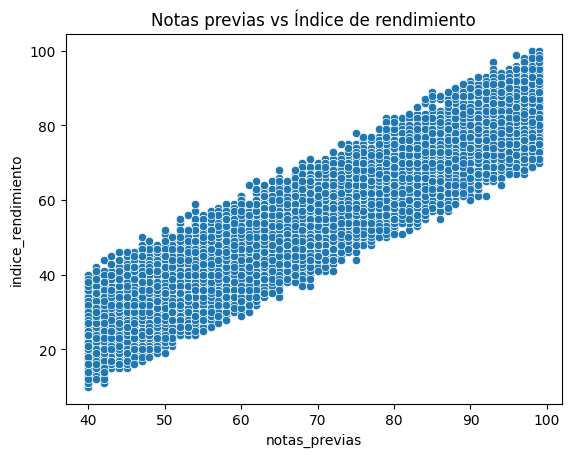

In [5]:
sns.scatterplot(data=data, x="notas_previas", y="indice_rendimiento")
plt.title("Notas previas vs Índice de rendimiento")
plt.show()

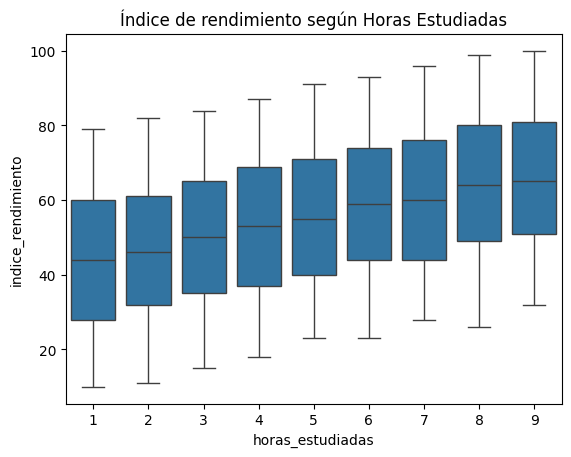

In [6]:
sns.boxplot(data=data, x="horas_estudiadas", y="indice_rendimiento")
plt.title("Índice de rendimiento según Horas Estudiadas")
plt.show()

Según los gráficos anteriores: ¿se observa alguna relación entre las variables independientes `notas_previas` y `horas_estudiadas` con la variable dependiente `indice_rendimiento`?

## Ajuste del modelo

Recordemos que la Regresión Lineal es una técnica estadística utilizada para modelar la relación entre una **variable dependiente** y una o más **variables independientes**.

En este contexto, nuestro objetivo es ajustar un modelo que nos permita predecir el **índice de rendimiento** basándonos en las variables `notas_previas` y `horas_estudiadas`.

---

Para realizar lo anterior, ejecute el código de la celda adyacente.

In [7]:
import statsmodels.api as sm

X = data[["notas_previas", "horas_estudiadas"]]
y = data["indice_rendimiento"]

X = sm.add_constant(X)

modelo = sm.OLS(y, X)
resultado = modelo.fit()

En base a lo anterior, responda:
- ¿Cuál es la variable dependiente $y$?
- ¿Cuál son las variables independientes $x_1$ y $x_2$?

## Comprobación de supuestos

1. **Linealidad**: La relación entre las variables independientes y la variable dependiente debe ser lineal. Si la relación es no lineal, los resultados de la regresión (lineal) pueden ser poco confiables y conducir a interpretaciones erróneas sobre la relación entre las variables.
2. **Normalidad**: Los errores de la regresión deben seguir una distribución normal.
3. **Homocedasticidad**: La varianza de los errores debe ser constante en todos los niveles de las variables predictoras.
4. **Independencia**: Los errores de la regresión no deben estar correlacionados entre sí. Si hay autocorrelación presente, puede afectar la precisión de los coeficientes y las pruebas de hipótesis, lo que lleva a conclusiones erróneas sobre la importancia de las variables predictoras.

### Comprobación de Linealidad

- Recuerde que una forma de comprobar la linealidad es comprobar si la <u>media de los residuos del modelo es igual, o cercana, a 0</u>.
---
Ejecute el código adyacente y **verifique si se cumple el supuesto de linealidad**.

In [9]:
residuos = resultado.resid
round(np.mean(residuos), 2)

np.float64(-0.0)

### Comprobación de Normalidad

- Recuerde que una forma de comprobar la normalidad de los residuos es analizar el **gráfico de Probabilidad Normal (Q-Q Plot)**.
- Este gráfico muestra si los cuantiles de los residuos coinciden con los cuantiles esperados de una distribución normal.
- Si los puntos en el gráfico forman aproximadamente una línea recta, esto sugiere que los residuos siguen una distribución normal.
---
Ejecute el código adyacente y **<u>verifique si se cumple el supuesto de normalidad</u>**.

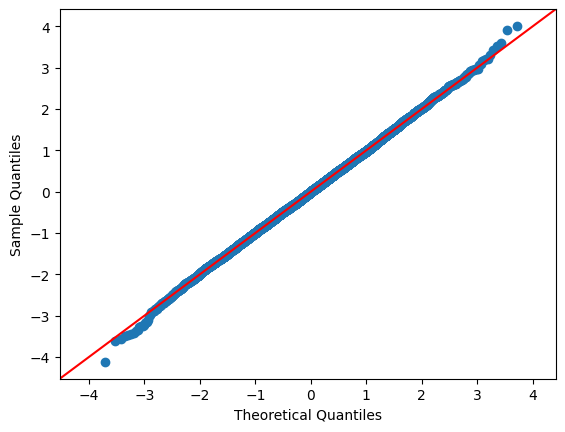

In [10]:
sm.qqplot(residuos, line='45', fit=True)
plt.show()

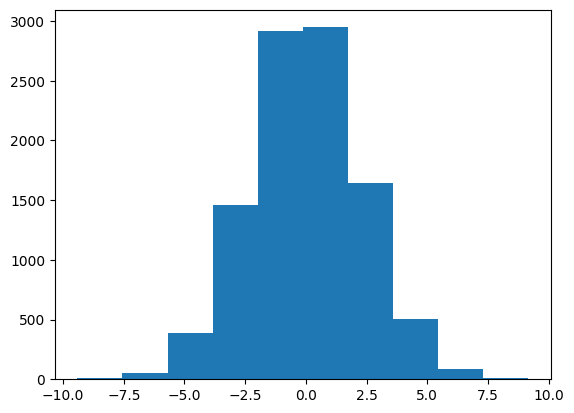

In [11]:
plt.hist(residuos)
plt.show()

### Comprobación de Homocedasticidad

- Recuerde que una forma de comprobar si se cumple el supuesto de homocedasticidad es con un gráfico de dispersión de los **residuos vs valores ajustados ($\hat{y}$)**.
- Lo que se busca es que los residuos presenten un patrón aleatorio alrededor de 0.
- Un patrón aleatorio sugiere que el modelo de regresión es apropiado y que los supuestos del modelo se cumplen.
---
Ejecute el código adyacente y **<u>verifique si se cumple el supuesto de homocedasticidad</u>**.

<>:3: SyntaxWarning: invalid escape sequence '\h'
<>:3: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_2468/269252567.py:3: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Valores Ajustados ($\hat{y}$)')


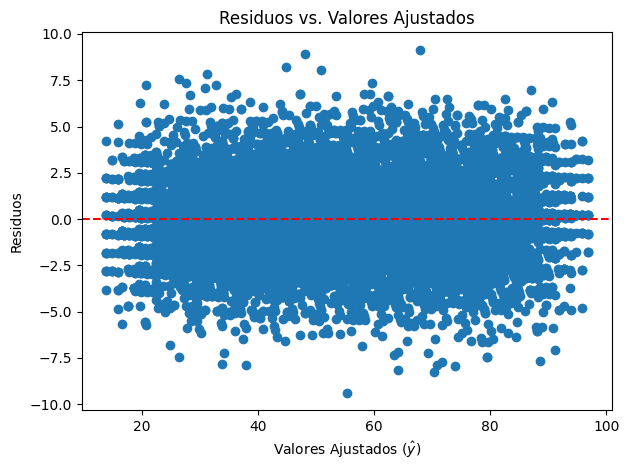

In [12]:
plt.scatter(resultado.fittedvalues, resultado.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores Ajustados ($\hat{y}$)')
plt.ylabel('Residuos')
plt.title('Residuos vs. Valores Ajustados')
plt.tight_layout()
plt.show()

- Otra forma de comprobar el supuesto, es utilizar la prueba estadística de Breusch-Pagan. Esta prueba plante las siguientes hipótesis:
  - $H_0$: La varianza de los errores es constante a lo largo de las observaciones, es decir, los errores son homocedásticos.
  - $H_1$: La varianza de los errores no es constante y depende de una o más variables independientes, es decir, los errores son *heterocedásticos*.
- Si el **valor-p de la prueba es menor que el nivel de significancia ($\alpha$)**, se rechaza la hipótesis nula, lo que sugiere la presencia de heterocedasticidad.
---
Ejecute el código adyacente y **<u>verifique si se cumple el supuesto de homocedasticidad</u>**.

In [13]:
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuos, resultado.model.exog)
bp_stat, bp_pvalue, _, _ = bp_test

print(f'Estadístico de Breusch-Pagan: {bp_stat}, valor-p: {bp_pvalue}')
print("Nivel de significancia: 0.05")
print(f"¿valor-p < 0.05?: {bp_pvalue < 0.05}")

Estadístico de Breusch-Pagan: 0.23156330023477167, valor-p: 0.8906696796869428
Nivel de significancia: 0.05
¿valor-p < 0.05?: False


### Comprobación de Independencia

- Recuerde que la prueba de Durbin-Watson es una prueba estadística que se utiliza para analizar la presencia de autocorrelación en los residuos de un modelo de regresión.
- El estadístico de Durbin-Watson toma valores entre 0 y 4.
  - Un valor cercano a 2 sugiere que **no hay autocorrelación**.
  - Los valores más cercanos a 0 indican **autocorrelación positiva**.
  - Los valores más cercanos a 4 indican **autocorrelación negativa**.
---
Ejecute el código adyacente y **<u>verifique si se cumple el supuesto de independencia</u>**.

In [14]:
from statsmodels.stats.stattools import durbin_watson

dw_stat = durbin_watson(residuos)
print(dw_stat)

1.9922442320929137


## Coeficientes de la Regresión Lineal

Los coeficientes **representan la relación entre la variable dependiente y cada una de las variables independientes**.

- **Intercepto ($\beta_0$)**: Este coeficiente representa el valor esperado de la variable dependiente cuando todas las variables independientes son cero. En muchos contextos, el intercepto puede no tener una interpretación práctica, especialmente si es imposible que las variables independientes tomen el valor cero simultáneamente en la realidad.
- **Coeficientes de regresión ($\beta_1, \beta_2, \dots, \beta_n$)**: Cada uno de estos coeficientes indica el cambio esperado en la variable dependiente por una unidad de cambio en la variable independiente correspondiente, manteniendo todas las demás variables independientes constantes.
  - **Positivo vs. Negativo**: Un coeficiente positivo indica que a medida que la variable independiente aumenta, la variable dependiente también tiende a aumentar, y viceversa para un coeficiente negativo.
  - **Magnitud**: La magnitud del coeficiente indica la fuerza de la influencia. Un coeficiente mayor implica un mayor impacto de la variable independiente sobre la dependiente.

---
 Ejecute el código adyacente e **<u>interprete los coeficientes del modelo:</u>** $\beta_0$, $\beta_1$ y  $\beta_2$.

In [15]:
resultado.params

,0
const,-29.816790
notas_previas,1.019123
horas_estudiadas,2.857637


$y = \beta_0 + \beta_1x_1 + \beta_2x_2$

$\text{indice rendimiento} = -29.82 + 1.02 \cdot \text{notas previas} + 2.86 \cdot \text{horas estudiadas}$

In [21]:
def modelo(notas_previas, horas_estudiadas):
  return -29.82 + (1.02 * notas_previas) + (2.86 * horas_estudiadas)

print(modelo(80, 10))

80.38


## Evaluación del modelo

### $R^2$

Recuerde que el **coeficiente de determinación $R^2$**, que nos indica la proporción de la variabilidad en la variable dependiente que es explicada por nuestro modelo.
- Un $R^2$ igual a 0 indica que el modelo no está capturando ninguna información útil sobre los datos.
- Un $R^2$ igual a 1 indica un ajuste perfecto del modelo a los datos. Esto significa que todas las variaciones en la variable de respuesta son explicadas por el modelo.
---
Ejecute el código adyacente e **<u>interprete el coeficiente de determinación $R^2$</u>**.

In [22]:
print(resultado.rsquared)

0.9858724242382322


### $R^2$ ajustado


- Recuerde que el $R^2$ ajustado ($R_a^2$) penaliza la inclusión de variables irrelevantes en el modelo.
---
Ejecute el código adyacente y **<u>observe si hay diferencias entre el </u>** $R^2$ y $R_a^2$.

In [23]:
print(resultado.rsquared_adj)

0.9858695978751709


### RMSE

- Recuerde que Error Cuadrático Medio (MSE) nos permite cuantificar los errores de nuestro modelo.
- El MSE calcula el promedio de los cuadrados de los errores, es decir, la diferencia cuadrática promedio entre los valores observados $y_i$ y los valores predichos $\hat{y}_i$.
- Por otro lado, el RMSE es simplemente la raíz cuadrada del MSE ($\text{RMSE}=\sqrt{\text{MSE}}$), pero la principal diferencia es que los errores en las mismas unidades que la variable de respuesta.
---
Ejecute el código adyacente e **<u>interprete el RMSE del modelo</u>**.

In [24]:
from statsmodels.tools.eval_measures import rmse

y_hat = resultado.fittedvalues
rmse_modelo = rmse(y, y_hat)
print(f"RMSE: {rmse_modelo}")

RMSE: 2.2834804288168735
